In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
import json
import pandas as pd

records = []
with open(str(Path('data/raw/Handmade_Products.jsonl')), 'r') as f:
    for line in f:
        d = json.loads(line.strip())
        records.append({
            'user_id': d['user_id'],
            'item_id': d['asin'],
            'rating': d['rating'],
            'timestamp': d['timestamp']
        })

df = pd.DataFrame(records)
print('Shape:', df.shape)
print('Unique users:', df['user_id'].nunique())
print('Unique items:', df['item_id'].nunique())
print('Nulls:', df.isnull().sum().to_dict())
print('Rating range:', df['rating'].min(), '-', df['rating'].max())


Shape: (664162, 4)
Unique users: 586613
Unique items: 176586
Nulls: {'user_id': 0, 'item_id': 0, 'rating': 0, 'timestamp': 0}
Rating range: 1.0 - 5.0


In [3]:
os.makedirs('plots', exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#2E75B6", "#FFC000", "#70AD47", "#FF5252"]
plt.rcParams.update({'figure.dpi': 150, 'savefig.bbox': 'tight'})

In [4]:
# =============================================================
# 5.1  LOAD RAW DATA
# =============================================================

print("\n" + "="*60)
print("5.1  LOADING RAW DATA")
print("="*60)

# ── MovieLens 1M ─────────────────────────────────────────────
print("\n[MovieLens 1M] Loading files...")

ml_ratings = pd.read_csv(
    str(Path('data/raw/ratings.dat')), sep='::', header=None,
    names=['UserID', 'MovieID', 'Rating', 'Timestamp'],
    engine='python'
)
ml_movies = pd.read_csv(
    str(Path('data/raw/movies.dat')), sep='::', header=None,
    names=['MovieID', 'Title', 'Genres'],
    engine='python', encoding='latin-1'
)
ml_users = pd.read_csv(
    str(Path('data/raw/users.dat')), sep='::', header=None,
    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip'],
    engine='python'
)

print(f"  ratings.dat  → {ml_ratings.shape[0]:,} rows, {ml_ratings.shape[1]} columns")
print(f"  movies.dat   → {ml_movies.shape[0]:,} rows, {ml_movies.shape[1]} columns")
print(f"  users.dat    → {ml_users.shape[0]:,} rows, {ml_users.shape[1]} columns")



5.1  LOADING RAW DATA

[MovieLens 1M] Loading files...
  ratings.dat  → 1,000,209 rows, 4 columns
  movies.dat   → 3,883 rows, 3 columns
  users.dat    → 6,040 rows, 5 columns


In [5]:
# ── Amazon Handmade Products ──────────────────────────────────
print("\n[Handmade Products] Loading file...")

records = []
with open(str(Path('data/raw/Handmade_Products.jsonl')), 'r') as f:
    for line in f:
        d = json.loads(line.strip())
        records.append({
            'UserID':    d.get('user_id'),
            'ItemID':    d.get('asin'),
            'Rating':    d.get('rating'),
            'Timestamp': d.get('timestamp'),
            'Verified':  d.get('verified_purchase', False)
        })

hm_raw = pd.DataFrame(records)
print(f"  Handmade_Products.jsonl → {hm_raw.shape[0]:,} rows, {hm_raw.shape[1]} columns")



[Handmade Products] Loading file...
  Handmade_Products.jsonl → 664,162 rows, 5 columns


In [6]:
# =============================================================
# 5.2  RAW DATA CHARACTERISTICS (BEFORE CLEANING)
# =============================================================

print("\n" + "="*60)
print("5.2  RAW DATA CHARACTERISTICS (BEFORE CLEANING)")
print("="*60)

def raw_stats(df, user_col, item_col, rating_col, name):
    n_users    = df[user_col].nunique()
    n_items    = df[item_col].nunique()
    n_ratings  = len(df)
    matrix     = n_users * n_items
    density    = n_ratings / matrix
    sparsity   = 1 - density
    nulls      = df.isnull().sum().sum()
    dups       = df.duplicated().sum()
    avg_u      = df.groupby(user_col).size().mean()
    min_u      = df.groupby(user_col).size().min()
    max_u      = df.groupby(user_col).size().max()
    r_min      = df[rating_col].min()
    r_max      = df[rating_col].max()

    print(f"\n  ── {name} ──")
    print(f"  Shape:                  {df.shape}")
    print(f"  Null values:            {nulls}")
    print(f"  Duplicate rows:         {dups}")
    print(f"  Unique users:           {n_users:,}")
    print(f"  Unique items:           {n_items:,}")
    print(f"  Total interactions:     {n_ratings:,}")
    print(f"  Rating range:           {r_min} – {r_max}")
    print(f"  Avg ratings / user:     {avg_u:.2f}")
    print(f"  Min ratings / user:     {min_u}")
    print(f"  Max ratings / user:     {max_u:,}")
    print(f"  Matrix size:            {n_users:,} × {n_items:,} = {matrix:,}")
    print(f"  Density:                {density:.6%}")
    print(f"  Sparsity:               {sparsity:.6%}")

    return {
        'Dataset': name, 'Users': n_users, 'Items': n_items,
        'Interactions': n_ratings, 'Density': density,
        'Sparsity': sparsity, 'Avg_per_user': avg_u,
        'Nulls': nulls, 'Duplicates': dups
    }

stats_ml = raw_stats(ml_ratings, 'UserID', 'MovieID', 'Rating', 'MovieLens 1M')
stats_hm = raw_stats(hm_raw,     'UserID', 'ItemID',  'Rating', 'Handmade Products (raw)')

# ── Side-by-side comparison table ────────────────────────────
print("\n\n  ── DATASET COMPARISON TABLE ──")
print(f"  {'Property':<30} {'MovieLens 1M':>20} {'Handmade Products':>20}")
print("  " + "-"*72)
rows = [
    ("Users",         f"{stats_ml['Users']:,}",       f"{stats_hm['Users']:,}"),
    ("Items",         f"{stats_ml['Items']:,}",       f"{stats_hm['Items']:,}"),
    ("Interactions",  f"{stats_ml['Interactions']:,}", f"{stats_hm['Interactions']:,}"),
    ("Density",       f"{stats_ml['Density']:.4%}",   f"{stats_hm['Density']:.6%}"),
    ("Sparsity",      f"{stats_ml['Sparsity']:.4%}",  f"{stats_hm['Sparsity']:.6%}"),
    ("Avg ratings/user", f"{stats_ml['Avg_per_user']:.2f}", f"{stats_hm['Avg_per_user']:.2f}"),
    ("Rating scale",  "1 – 5",                        "1 – 5"),
    ("Feedback type", "Explicit",                     "Explicit"),
    ("Domain",        "Movies",                       "Small business e-commerce"),
]
for r in rows:
    print(f"  {r[0]:<30} {r[1]:>20} {r[2]:>20}")


5.2  RAW DATA CHARACTERISTICS (BEFORE CLEANING)

  ── MovieLens 1M ──
  Shape:                  (1000209, 4)
  Null values:            0
  Duplicate rows:         0
  Unique users:           6,040
  Unique items:           3,706
  Total interactions:     1,000,209
  Rating range:           1 – 5
  Avg ratings / user:     165.60
  Min ratings / user:     20
  Max ratings / user:     2,314
  Matrix size:            6,040 × 3,706 = 22,384,240
  Density:                4.468363%
  Sparsity:               95.531637%

  ── Handmade Products (raw) ──
  Shape:                  (664162, 5)
  Null values:            0
  Duplicate rows:         7378
  Unique users:           586,613
  Unique items:           176,586
  Total interactions:     664,162
  Rating range:           1.0 – 5.0
  Avg ratings / user:     1.13
  Min ratings / user:     1
  Max ratings / user:     35
  Matrix size:            586,613 × 176,586 = 103,587,643,218
  Density:                0.000641%
  Sparsity:               99

In [7]:
# =============================================================
# 5.3  PREPROCESSING AND CLEANING
# =============================================================

print("\n" + "="*60)
print("5.3  PREPROCESSING AND CLEANING")
print("="*60)

# ── MovieLens: already clean by design ───────────────────────
print("\n[MovieLens 1M]")
print(f"  Null values:       {ml_ratings.isnull().sum().sum()}")
print(f"  Duplicate rows:    {ml_ratings.duplicated().sum()}")
print(f"  Min ratings/user:  {ml_ratings.groupby('UserID').size().min()} (guaranteed ≥20 by dataset design)")
print("  → No rows dropped. Dataset is clean.")

# Convert explicit ratings to implicit binary (threshold ≥ 4)
THRESHOLD = 4
ml_clean = ml_ratings[ml_ratings['Rating'] >= THRESHOLD].copy()
ml_clean = ml_clean[['UserID', 'MovieID', 'Rating', 'Timestamp']].drop_duplicates()

print(f"\n  Implicit conversion (rating ≥ {THRESHOLD}):")
print(f"  Before: {len(ml_ratings):,} interactions")
print(f"  After:  {len(ml_clean):,} positive interactions")
print(f"  Dropped: {len(ml_ratings) - len(ml_clean):,} low-rated interactions")

# Reindex IDs
ml_clean['UserID_idx'] = ml_clean['UserID'].astype('category').cat.codes
ml_clean['ItemID_idx'] = ml_clean['MovieID'].astype('category').cat.codes
print(f"  IDs reindexed: Users 0–{ml_clean['UserID_idx'].max()}, Items 0–{ml_clean['ItemID_idx'].max()}")

# ── Handmade Products: full cleaning pipeline ─────────────────
print("\n[Handmade Products]")
print(f"  Raw shape:         {hm_raw.shape}")
print(f"  Null values:       {hm_raw.isnull().sum().to_dict()}")
print(f"  Duplicate rows:    {hm_raw.duplicated().sum()}")

# Step 1: Remove nulls
hm = hm_raw.dropna(subset=['UserID', 'ItemID', 'Rating']).copy()
print(f"\n  Step 1 – Remove nulls:      {len(hm_raw):,} → {len(hm):,} rows")

# Step 2: Remove duplicates
hm = hm.drop_duplicates(subset=['UserID', 'ItemID'])
print(f"  Step 2 – Remove duplicates: {len(hm_raw):,} → {len(hm):,} rows")

# Step 3: Filter invalid ratings
hm = hm[(hm['Rating'] >= 1) & (hm['Rating'] <= 5)]
print(f"  Step 3 – Valid ratings:     {len(hm):,} rows remain")

# Step 4: Minimum interaction threshold (keep users with >= 2 interactions)
MIN_INTERACTIONS = 2
user_counts = hm.groupby('UserID').size()
valid_users = user_counts[user_counts >= MIN_INTERACTIONS].index
hm = hm[hm['UserID'].isin(valid_users)]
print(f"  Step 4 – Min {MIN_INTERACTIONS} interactions/user: {len(hm):,} rows, {hm['UserID'].nunique():,} users remain")

# Step 5: Convert to implicit binary (threshold >= 4)
hm_clean = hm[hm['Rating'] >= THRESHOLD].copy()
print(f"\n  Implicit conversion (rating ≥ {THRESHOLD}):")
print(f"  Before: {len(hm):,} interactions")
print(f"  After:  {len(hm_clean):,} positive interactions")

# Step 6: Reindex IDs
hm_clean['UserID_idx'] = hm_clean['UserID'].astype('category').cat.codes
hm_clean['ItemID_idx'] = hm_clean['ItemID'].astype('category').cat.codes
print(f"  IDs reindexed: Users 0–{hm_clean['UserID_idx'].max()}, Items 0–{hm_clean['ItemID_idx'].max()}")

# ── Post-cleaning sparsity stats ──────────────────────────────
print("\n  ── POST-CLEANING STATS ──")
for name, df, u_col, i_col in [
    ("MovieLens 1M (clean)",      ml_clean,  'UserID_idx', 'ItemID_idx'),
    ("Handmade Products (clean)", hm_clean,  'UserID_idx', 'ItemID_idx'),
]:
    nu = df[u_col].nunique()
    ni = df[i_col].nunique()
    nr = len(df)
    d  = nr / (nu * ni)
    print(f"\n  {name}")
    print(f"    Users: {nu:,}  |  Items: {ni:,}  |  Interactions: {nr:,}")
    print(f"    Density: {d:.6%}  |  Sparsity: {1-d:.6%}")


# =============================================================
# 5.4  EXPLORATORY DATA ANALYSIS — PLOTS
# =============================================================

print("\n" + "="*60)
print("5.4  GENERATING EDA PLOTS")
print("="*60)

# ────────────────────────────────────────────────────────────
# PLOT 1: Rating Distribution — MovieLens
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 1 – Rating Distribution", fontsize=14, fontweight='bold')

counts_ml = ml_ratings['Rating'].value_counts().sort_index()
axes[0].bar(counts_ml.index, counts_ml.values, color=PALETTE[0], edgecolor='white', width=0.6)
axes[0].set_title("MovieLens 1M", fontsize=12)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Ratings")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for i, v in zip(counts_ml.index, counts_ml.values):
    axes[0].text(i, v + 3000, f'{v/len(ml_ratings)*100:.1f}%', ha='center', fontsize=9)

counts_hm = hm_raw['Rating'].value_counts().sort_index()
axes[1].bar(counts_hm.index, counts_hm.values, color=PALETTE[1], edgecolor='white', width=0.6)
axes[1].set_title("Amazon Handmade Products", fontsize=12)
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Ratings")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for i, v in zip(counts_hm.index, counts_hm.values):
    axes[1].text(i, v + 1000, f'{v/len(hm_raw)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/fig1_rating_distribution.png')
plt.close()
print("  ✓ Saved: plots/fig1_rating_distribution.png")

# ────────────────────────────────────────────────────────────
# PLOT 2: Interactions per User Distribution
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 2 – Interactions per User Distribution", fontsize=14, fontweight='bold')

ml_user_counts = ml_ratings.groupby('UserID').size()
axes[0].hist(ml_user_counts, bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_title("MovieLens 1M", fontsize=12)
axes[0].set_xlabel("Number of Ratings per User")
axes[0].set_ylabel("Number of Users")
axes[0].axvline(ml_user_counts.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {ml_user_counts.mean():.1f}')
axes[0].axvline(ml_user_counts.median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {ml_user_counts.median():.0f}')
axes[0].legend(fontsize=9)

hm_user_counts = hm_raw.groupby('UserID').size()
axes[1].hist(hm_user_counts, bins=50, color=PALETTE[1], edgecolor='white')
axes[1].set_title("Amazon Handmade Products", fontsize=12)
axes[1].set_xlabel("Number of Ratings per User")
axes[1].set_ylabel("Number of Users")
axes[1].axvline(hm_user_counts.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {hm_user_counts.mean():.2f}')
axes[1].axvline(hm_user_counts.median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {hm_user_counts.median():.0f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/fig2_interactions_per_user.png')
plt.close()
print("  ✓ Saved: plots/fig2_interactions_per_user.png")

# ────────────────────────────────────────────────────────────
# PLOT 3: Interactions per Item Distribution
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 3 – Interactions per Item Distribution", fontsize=14, fontweight='bold')

ml_item_counts = ml_ratings.groupby('MovieID').size()
axes[0].hist(ml_item_counts, bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_title("MovieLens 1M", fontsize=12)
axes[0].set_xlabel("Number of Ratings per Item")
axes[0].set_ylabel("Number of Items")
axes[0].axvline(ml_item_counts.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {ml_item_counts.mean():.1f}')
axes[0].legend(fontsize=9)

hm_item_counts = hm_raw.groupby('ItemID').size()
axes[1].hist(hm_item_counts, bins=50, color=PALETTE[1], edgecolor='white')
axes[1].set_title("Amazon Handmade Products", fontsize=12)
axes[1].set_xlabel("Number of Ratings per Item")
axes[1].set_ylabel("Number of Items")
axes[1].axvline(hm_item_counts.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {hm_item_counts.mean():.2f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/fig3_interactions_per_item.png')
plt.close()
print("  ✓ Saved: plots/fig3_interactions_per_item.png")

# ────────────────────────────────────────────────────────────
# PLOT 4: Sparsity Comparison Bar Chart
# ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Figure 4 – Sparsity Comparison", fontsize=14, fontweight='bold')

datasets   = ['MovieLens 1M', 'Handmade Products']
sparsities = [
    (1 - stats_ml['Density']) * 100,
    (1 - stats_hm['Density']) * 100
]
bars = ax.bar(datasets, sparsities, color=[PALETTE[0], PALETTE[1]],
              edgecolor='white', width=0.4)
ax.set_ylabel("Sparsity (%)")
ax.set_ylim([94, 100.5])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
for bar, val in zip(bars, sparsities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.4f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/fig4_sparsity_comparison.png')
plt.close()
print("  ✓ Saved: plots/fig4_sparsity_comparison.png")

# ────────────────────────────────────────────────────────────
# PLOT 5: MovieLens Genre Distribution
# ────────────────────────────────────────────────────────────
genre_series = ml_movies['Genres'].str.split('|').explode()
genre_counts = genre_series.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure 5 – MovieLens Genre Distribution", fontsize=14, fontweight='bold')
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Blues_r', ax=ax)
ax.set_xlabel("Number of Movies")
ax.set_ylabel("Genre")
for i, v in enumerate(genre_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/fig5_movielens_genres.png')
plt.close()
print("  ✓ Saved: plots/fig5_movielens_genres.png")

# ────────────────────────────────────────────────────────────
# PLOT 6: Sparsity Simulation Levels — MovieLens
# ────────────────────────────────────────────────────────────
levels     = ['100%\n(Full)', '50%', '25%', '10%', 'Handmade\n(Real-world)']
densities  = [
    stats_ml['Density'] * 100,
    stats_ml['Density'] * 0.50 * 100,
    stats_ml['Density'] * 0.25 * 100,
    stats_ml['Density'] * 0.10 * 100,
    stats_hm['Density'] * 100
]
colors = [PALETTE[0], PALETTE[0], PALETTE[0], PALETTE[0], PALETTE[1]]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure 6 – Interaction Density Across Experimental Conditions",
             fontsize=13, fontweight='bold')
bars = ax.bar(levels, densities, color=colors, edgecolor='white', width=0.5)
ax.set_ylabel("Interaction Density (%)")
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.4f}%'))
for bar, val in zip(bars, densities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'{val:.4f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel("Experimental Condition")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[0], label='MovieLens (simulated sparsity levels)'),
    Patch(facecolor=PALETTE[1], label='Handmade Products (real-world extreme sparsity)')
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('plots/fig6_sparsity_levels.png')
plt.close()
print("  ✓ Saved: plots/fig6_sparsity_levels.png")

# ────────────────────────────────────────────────────────────
# PLOT 7: User Activity Percentile — Long Tail
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figure 7 – Long Tail Effect: User Activity Distribution",
             fontsize=13, fontweight='bold')

for ax, counts, name, color in [
    (axes[0], ml_user_counts.sort_values(ascending=False).reset_index(drop=True),
     'MovieLens 1M', PALETTE[0]),
    (axes[1], hm_user_counts.sort_values(ascending=False).reset_index(drop=True),
     'Handmade Products', PALETTE[1])
]:
    ax.plot(range(len(counts)), counts.values, color=color, linewidth=1.5)
    ax.fill_between(range(len(counts)), counts.values, alpha=0.2, color=color)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Users (ranked by activity)")
    ax.set_ylabel("Number of Interactions")
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('plots/fig7_long_tail.png')
plt.close()
print("  ✓ Saved: plots/fig7_long_tail.png")


# =============================================================
# FINAL SUMMARY
# =============================================================

print("\n" + "="*60)
print("DONE — All stats printed and 7 plots saved to /plots")
print("="*60)
print("\nPlots generated:")
plots = [
    "fig1_rating_distribution.png       → Section 5.4",
    "fig2_interactions_per_user.png     → Section 5.4",
    "fig3_interactions_per_item.png     → Section 5.4",
    "fig4_sparsity_comparison.png       → Section 5.2",
    "fig5_movielens_genres.png          → Section 5.4",
    "fig6_sparsity_levels.png           → Section 5.2",
    "fig7_long_tail.png                 → Section 5.4",
]
for p_name in plots:
    print(f"  {p_name}")

print("\nNext step: Run this script, then send the output screenshots")
print("and we will write the full Section 5 written text together.\n")


5.3  PREPROCESSING AND CLEANING

[MovieLens 1M]
  Null values:       0
  Duplicate rows:    0
  Min ratings/user:  20 (guaranteed ≥20 by dataset design)
  → No rows dropped. Dataset is clean.

  Implicit conversion (rating ≥ 4):
  Before: 1,000,209 interactions
  After:  575,281 positive interactions
  Dropped: 424,928 low-rated interactions
  IDs reindexed: Users 0–6037, Items 0–3532

[Handmade Products]
  Raw shape:         (664162, 5)
  Null values:       {'UserID': 0, 'ItemID': 0, 'Rating': 0, 'Timestamp': 0, 'Verified': 0}
  Duplicate rows:    7378

  Step 1 – Remove nulls:      664,162 → 664,162 rows
  Step 2 – Remove duplicates: 664,162 → 656,784 rows
  Step 3 – Valid ratings:     656,784 rows remain
  Step 4 – Min 2 interactions/user: 120,884 rows, 50,713 users remain

  Implicit conversion (rating ≥ 4):
  Before: 120,884 interactions
  After:  108,904 positive interactions
  IDs reindexed: Users 0–48892, Items 0–60448

  ── POST-CLEANING STATS ──

  MovieLens 1M (clean)
    U

In [ ]:
# ────────────────────────────────────────────────────────────
# Save cleaned datasets for the next notebook
# ────────────────────────────────────────────────────────────
os.makedirs('saved', exist_ok=True)
ml_clean.to_pickle('saved/ml_clean.pkl')
ml_movies.to_pickle('saved/ml_movies.pkl')
hm_clean.to_pickle('saved/hm_clean.pkl')
print("\n  Saved cleaned datasets to saved/:")
print(f"    - saved/ml_clean.pkl ({len(ml_clean):,} rows)")
print(f"    - saved/ml_movies.pkl ({len(ml_movies):,} rows)")
print(f"    - saved/hm_clean.pkl ({len(hm_clean):,} rows)")

fig1_rating_distribution.png


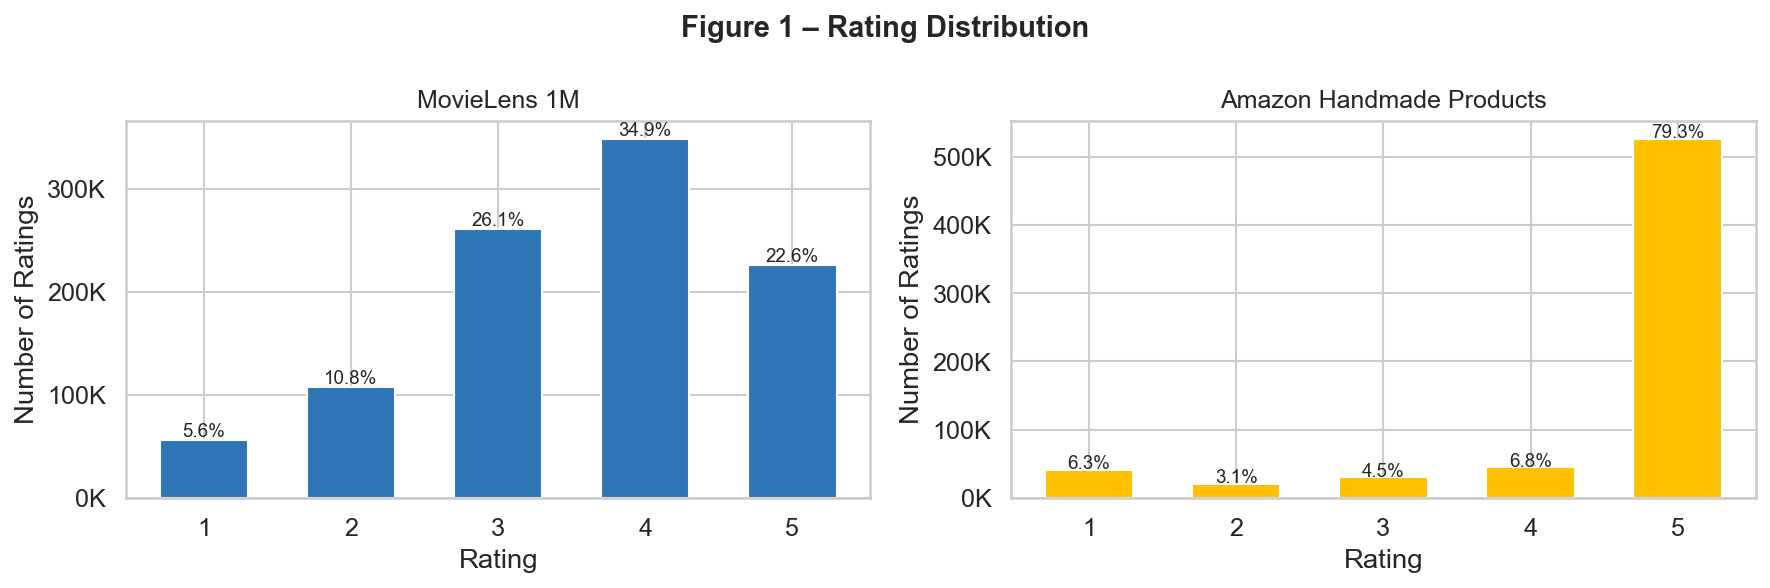

fig2_interactions_per_user.png


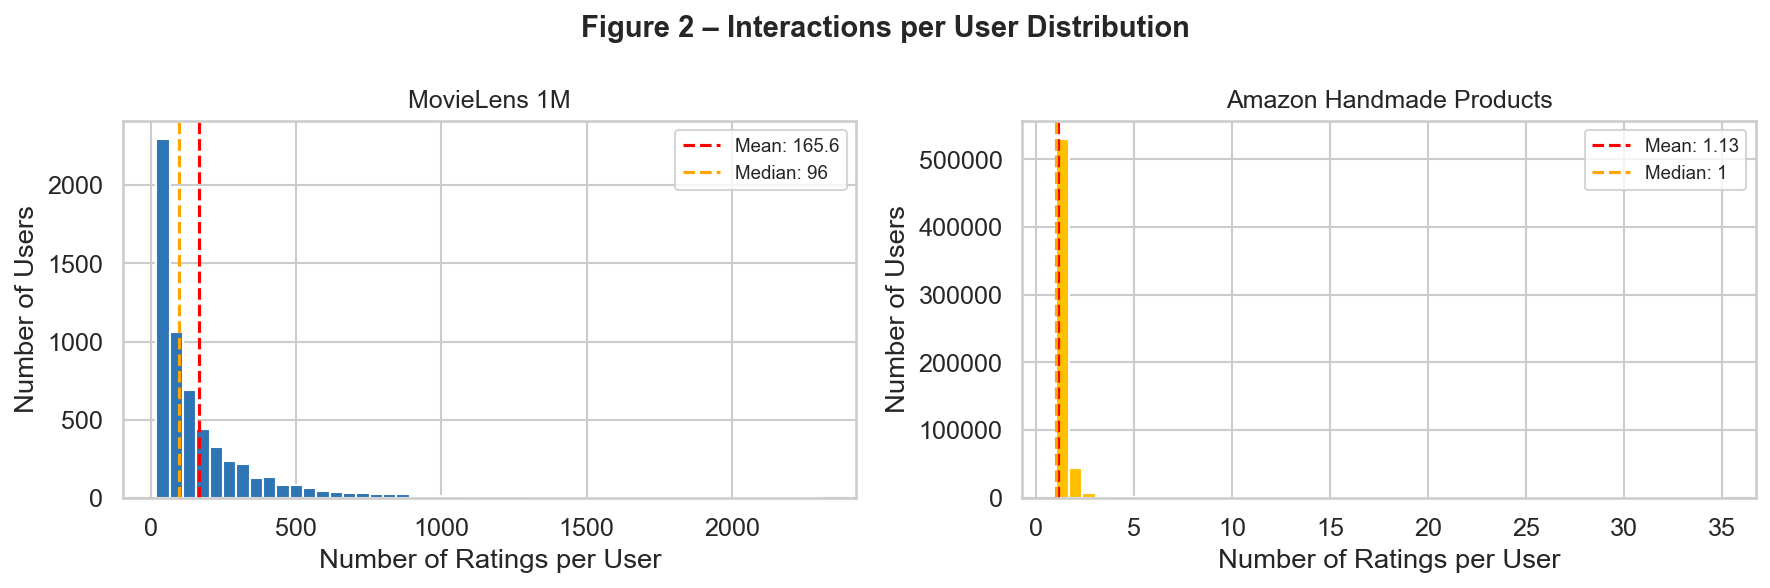

fig3_interactions_per_item.png


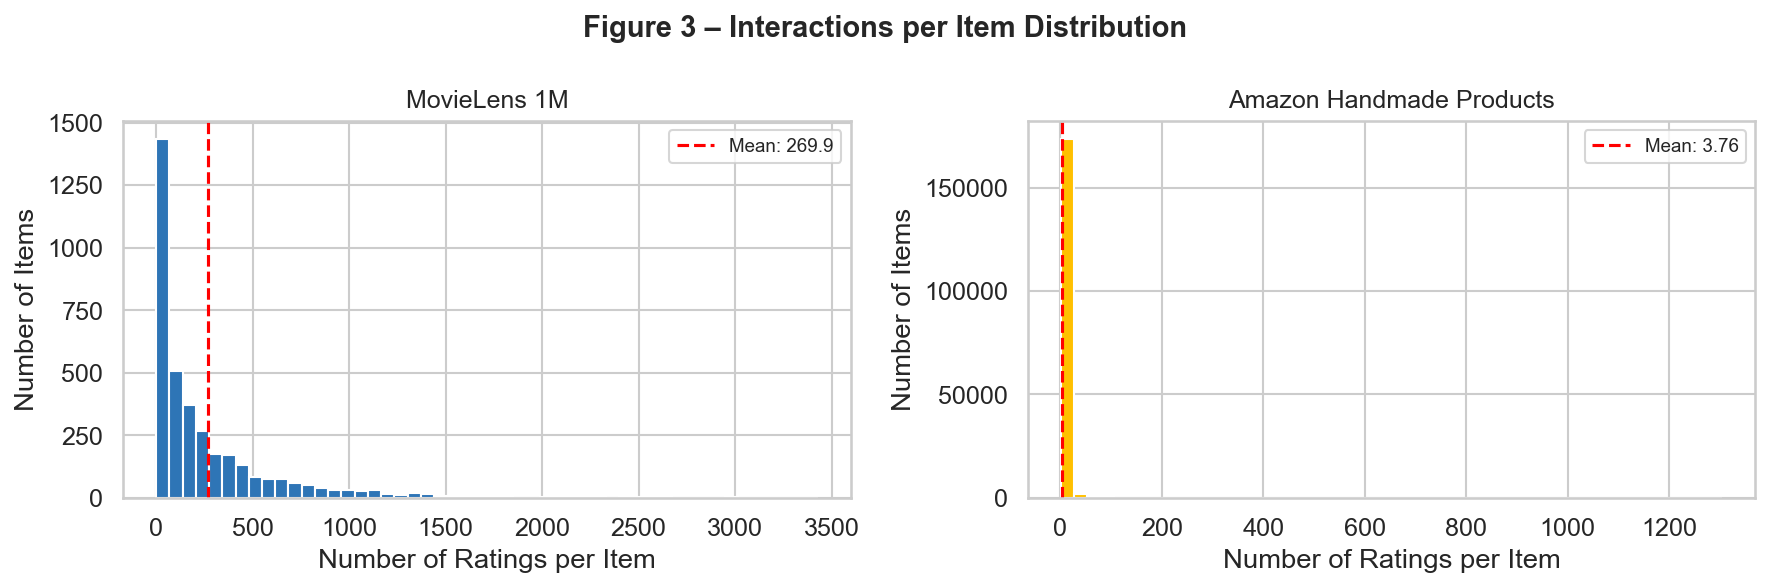

fig4_sparsity_comparison.png


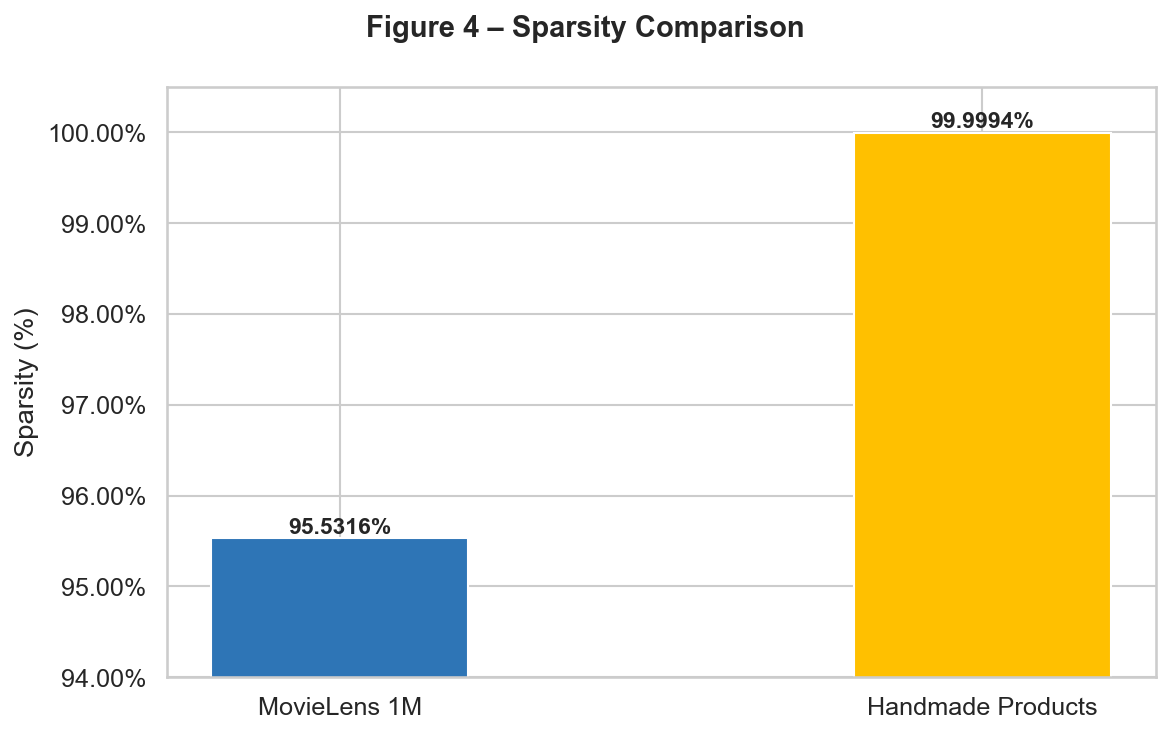

fig5_movielens_genres.png


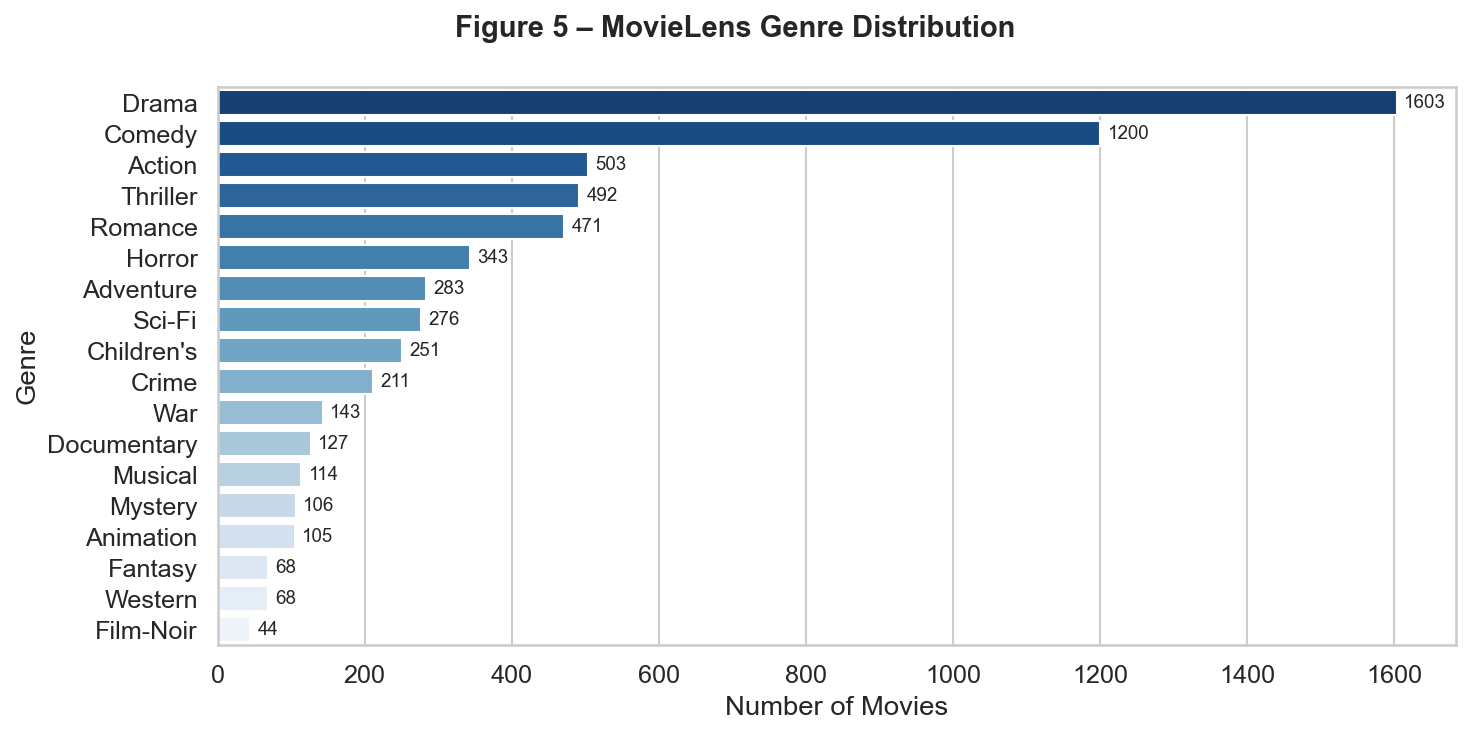

fig6_sparsity_levels.png


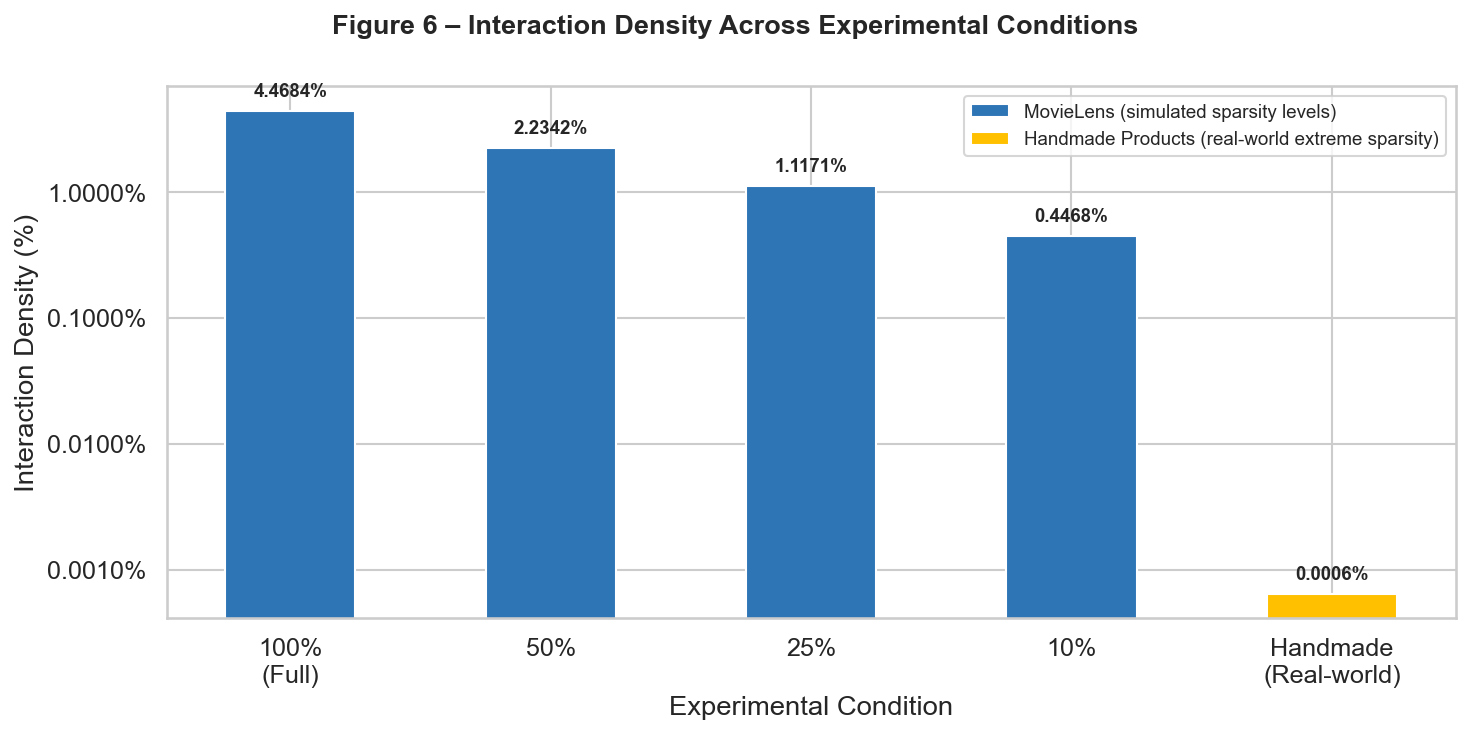

fig7_long_tail.png


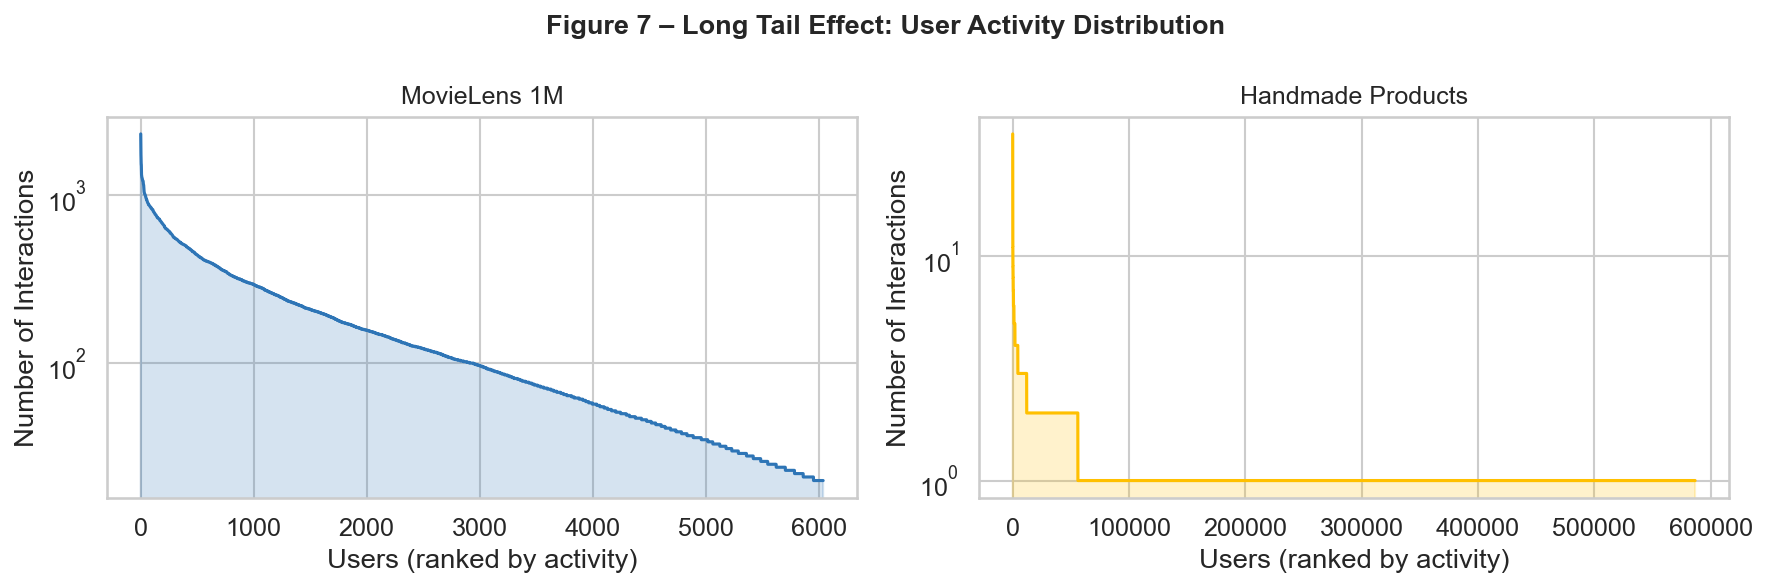

In [8]:
from IPython.display import Image, display
import os

for f in sorted(os.listdir('plots')):
    print(f)
    display(Image(f'plots/{f}'))